**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 6**
Ingeniería de características (FE)

---

*   EQUIPO 28   
*   INTEGRANTES :
*   TERESA DE JESUS MORENO MARTINEZ -A01840597
*   FRIDA ALEJANDRA MOYAO LEÓN -
*   ANA CRISTINA MUNGUIA ROMERO -
*   MARCO ANTONIO MUÑOZ CHAVEZ -

En esta actividad trabajarás con el archivo `computer_prices.csv`, basado en un conjunto de datos sobre características técnicas y especificaciones de computadoras portátiles y de escritorio, disponible en Kaggle.

Los datos fueron recopilados para analizar el rendimiento y el precio de los dispositivos, e incluyen información sobre hardware, almacenamiento, conectividad y otras especificaciones técnicas. Los indicadores incluidos son:

* `device_type`: Tipo de dispositivo (ej. laptop, desktop)
* `brand`: Marca del dispositivo
* `model`: Modelo del dispositivo
* `release_year`: Año de lanzamiento del dispositivo
* `os`: Sistema operativo instalado
* `form_factor`: Factor de forma o diseño del dispositivo (ej. laptop, ultrabook, desktop tower)
* `cpu_brand`: Marca del procesador
* `cpu_tier`: Nivel o gama del procesador, ordinal del 1 al 6 según desempeño
* `cpu_cores`: Número de núcleos del procesador
* `cpu_threads`: Número de hilos de ejecución del procesador
* `gpu_brand`: Marca de la tarjeta gráfica
* `gpu_model`: Modelo específico de la tarjeta gráfica
* `gpu_tier`: Nivel o gama de la GPU, ordinal del 1 al 6 según desempeño
* `vram_gb`: Memoria de video de la GPU en gigabytes
* `ram_gb`: Memoria RAM del dispositivo en gigabytes
* `storage_type`: Tipo de almacenamiento (ej. HDD, SSD)
* `storage_gb`: Capacidad de almacenamiento en gigabytes
* `storage_drive_count`: Número de unidades de almacenamiento instaladas
* `display_type`: Tipo de pantalla (ej. IPS, TN, OLED)
* `charger_watts`: Potencia del cargador (en watts) para laptops
* `psu_watts`: Potencia de la fuente de poder (en watts) para desktops
* `wifi`: Estándar de conectividad Wi-Fi (ej. Wi-Fi 5, 6, 6E, 7)
* `bluetooth`: Versión de Bluetooth
* `weight_kg`: Peso del dispositivo en kilogramos
* `warranty_months`: Meses de garantía del dispositivo
* `price`: Precio del dispositivo. Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [1]:
# Instalar las bibliotecas necesarias
!pip install category_encoders

In [2]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from scipy.stats import probplot
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import FunctionTransformer, PowerTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from category_encoders.binary import BinaryEncoder

1. Descarga el archivo: `computer_prices.csv` y guarda, en un dataframe (`compu_df`), todos sus registros.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Determina la cantidad de valores únicos por columna.
* Elimina las variables:
  * `model`: Debido a su altísima cardinalidad, lo que dificulta su uso en análisis y modelado.
  * `cpu_model`: Además de su elevada cardinalidad, su información ya está representada de manera implícita en otras variables como: `cpu_tier`, `cpu_cores` y `cpu_threads`

In [3]:
#1.Descarga el archivo: computer_prices.csv y guarda, en un dataframe (compu_df), todos sus registros.
compu_df=pd.read_csv ('computer_prices.csv')

#Utiliza el método info() del dataframe, para obtener el resumen de los tipos de datos.
#¿Cuántas columnas son numéricas y cuántas de texto?
print(compu_df.info)

#¿Cuántas columnas son numéricas ?
num_columnas_numericas = len(compu_df.select_dtypes(include=['number']).columns)
print(f"Columnas numéricas: {num_columnas_numericas}")

#¿Cuántas columnas son de texto ?
num_columnas_texto = len(compu_df.select_dtypes(include=['object', 'string']).columns)
print(f"Columnas de texto: {num_columnas_texto}")

#Determina la cantidad de valores únicos por columna.
valores_unicos = compu_df.nunique()
print(f"Valores únicos por columna: {valores_unicos}")

#Elimina las variables: model Y cpu_model
compu_df.drop(['model', 'cpu_model'], axis=1, inplace=True)
total_columnas = len(compu_df.columns)
print(f"Número de columnas: {total_columnas}")

<bound method DataFrame.info of       device_type     brand               model  release_year       os  \
0         Desktop   Samsung   Samsung Forge XDI          2022  Windows   
1          Laptop   Samsung     Samsung Pro KM8          2022  Windows   
2         Desktop    Lenovo    Lenovo Strix BIE          2024    macOS   
3         Desktop      Dell       Dell Cube AXR          2024  Windows   
4          Laptop  Gigabyte    Gigabyte Pro IX1          2024    Linux   
...           ...       ...                 ...           ...      ...   
99995      Laptop      ASUS        ASUS Pro ZWL          2023  Windows   
99996      Laptop    Lenovo  Lenovo Stealth 014          2018  Windows   
99997      Laptop      ASUS        ASUS Zen LKD          2020  Windows   
99998      Laptop      ASUS      ASUS Blade DH6          2020  Windows   
99999     Desktop      Acer      Acer Think L7R          2023  Windows   

      form_factor cpu_brand         cpu_model  cpu_tier  cpu_cores  ...  \
0   

2. Antes de iniciar con el análisis univariado, verifica si hay valores duplicados y/o faltantes.
* Obtén las estadísticas descriptivas, separado las numéricas y las categóricas. De estas últimas incluye las tablas de frecuencia.
* Genera histogramas para las numéricas y diagramas de barras para las categóricas. Con alta cardinalidad, sólo incluye los 10 valores más frecuentes.

In [4]:
#2Se verifica si hay valores faltantes o duplicados
print("\nTotal de valores faltantes:", compu_df.isnull().sum().sum())
print("\nTotal de filas duplicadas idénticas:", compu_df.duplicated().sum())



Total de valores faltantes: 0

Total de filas duplicadas idénticas: 0


In [5]:
#2.1 Obtén las estadísticas descriptivas,
# separando las numéricas y las categóricas.
# De estas últimas incluye las tablas de frecuencia.
numeric_desc = compu_df.describe()

print("--- ESTADÍSTICAS DESCRIPTIVAS (Numéricas) ---")
print(numeric_desc)
print("\n" + "="*50 + "\n")

categorical_desc = compu_df.describe(include=['O'])
print("--- ESTADÍSTICAS CATEGÓRICAS (Top, Frecuencia, Unicos) ---")
print(categorical_desc)
print("\n" + "="*50 + "\n")


print("--- TABLAS DE FRECUENCIA  ---")
categorical_cols = compu_df.select_dtypes(include=['O']).columns

for col in categorical_cols:
    print(f"\nTabla de Frecuencia para: {col}")
    freq_table = compu_df[col].value_counts().reset_index()
    freq_table.columns = [col, 'Frecuencia Absoluta']
    freq_table['Frecuencia Relativa (%)'] = (compu_df[col].value_counts(normalize=True) * 100).values
    print(freq_table)

--- ESTADÍSTICAS DESCRIPTIVAS (Numéricas) ---
        release_year       cpu_tier      cpu_cores    cpu_threads  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean     2022.320850       3.153490      10.515740      19.372700   
std         2.025761       1.373175       5.044092       9.718426   
min      2018.000000       1.000000       4.000000       4.000000   
25%      2021.000000       2.000000       6.000000      12.000000   
50%      2023.000000       3.000000       8.000000      16.000000   
75%      2024.000000       4.000000      14.000000      24.000000   
max      2025.000000       6.000000      28.000000      56.000000   

            gpu_tier        vram_gb         ram_gb     storage_gb  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean        2.991350       6.152180      39.706400     903.936000   
std         1.459643       3.964926      31.902684     774.243654   
min         1.000000       0.000000       8.000000     2


--- Histogramas para Variables Numéricas ---


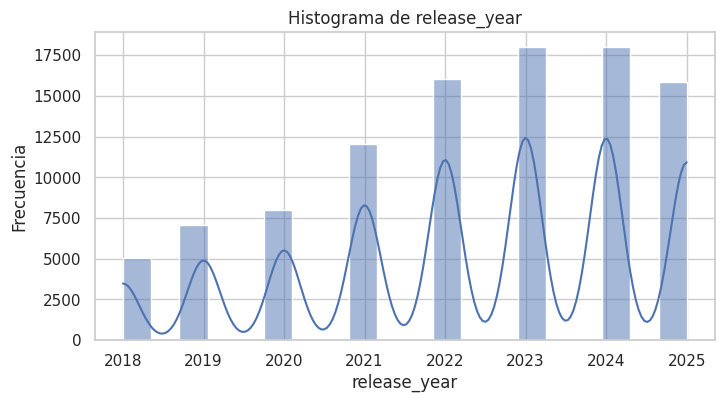

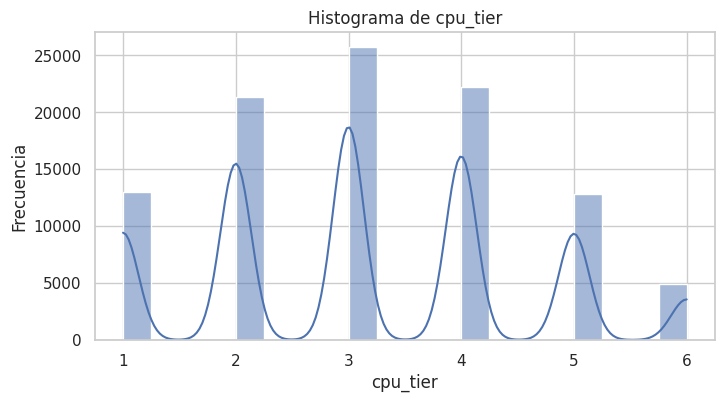

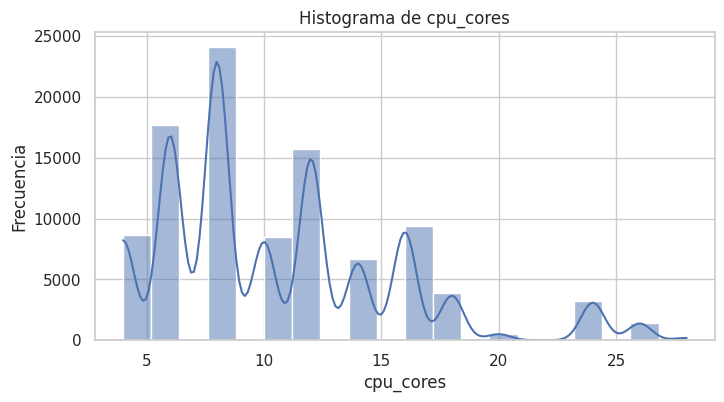

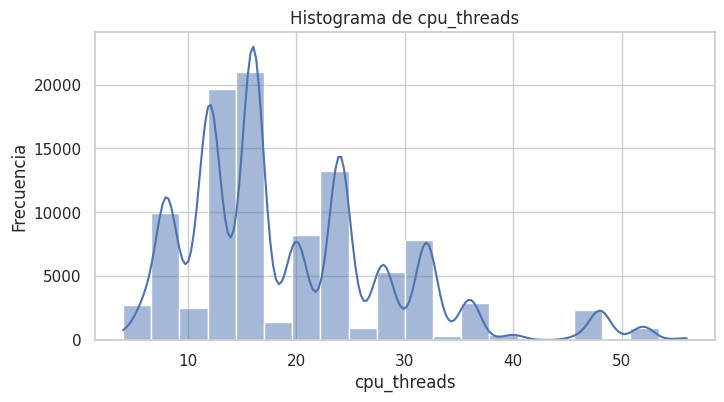

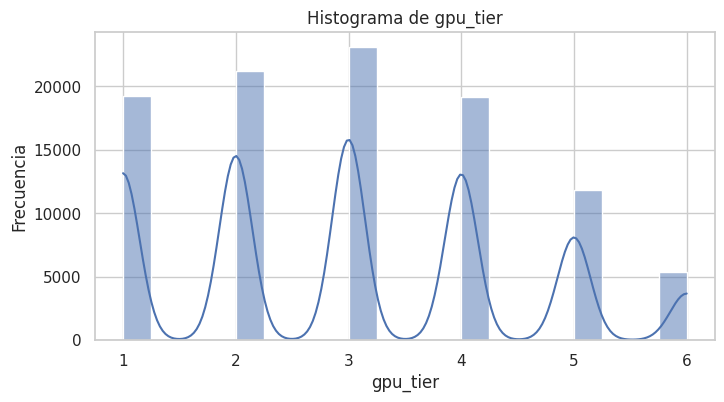

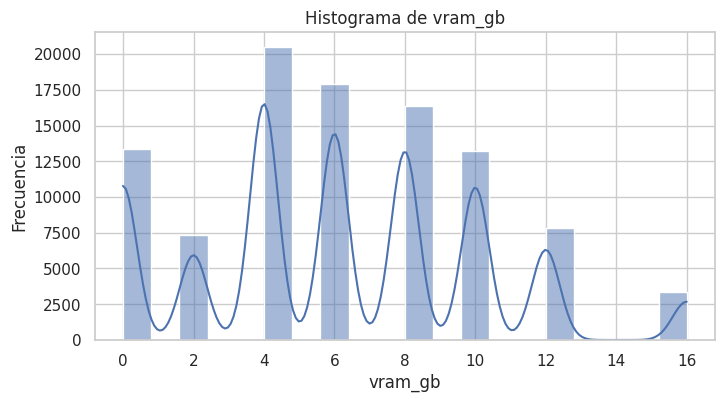

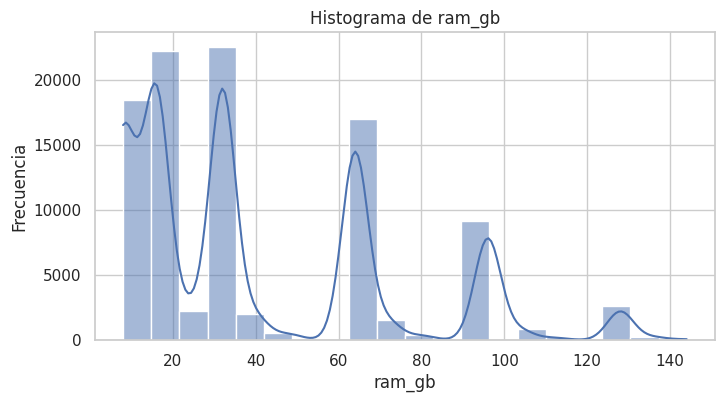

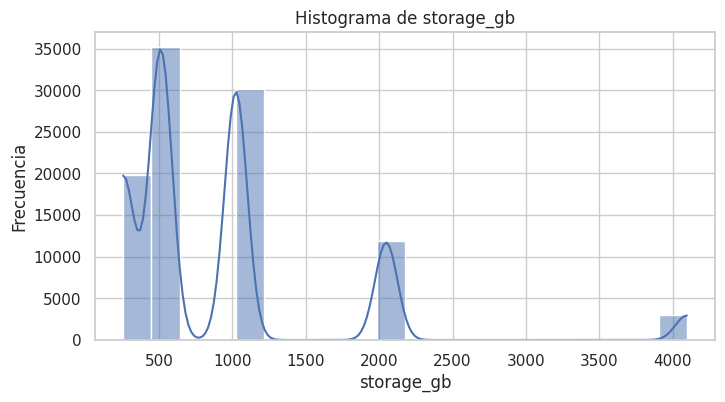

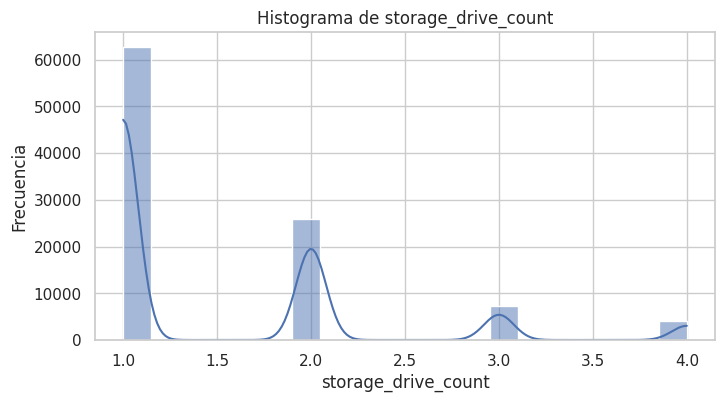

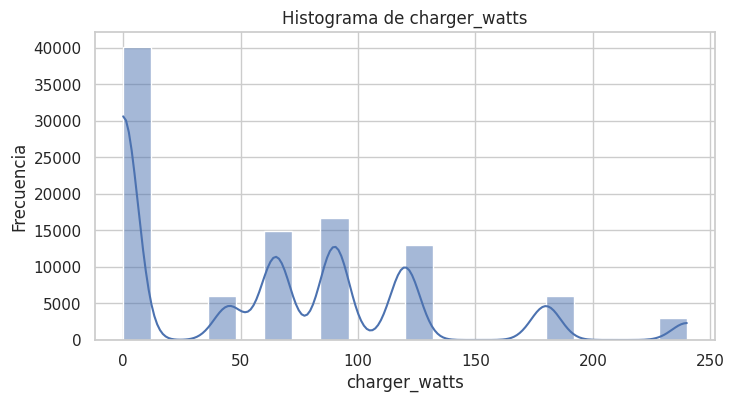

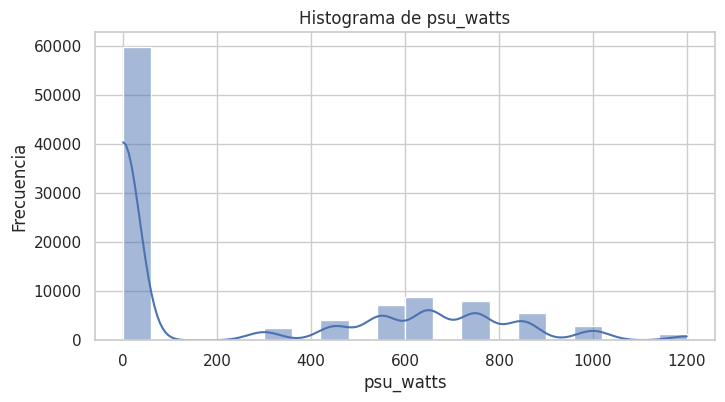

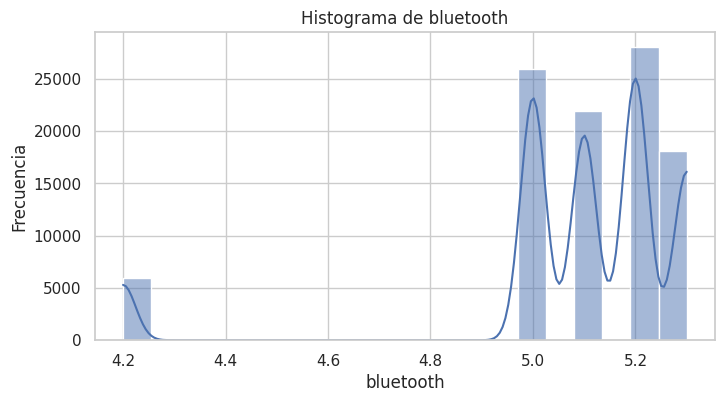

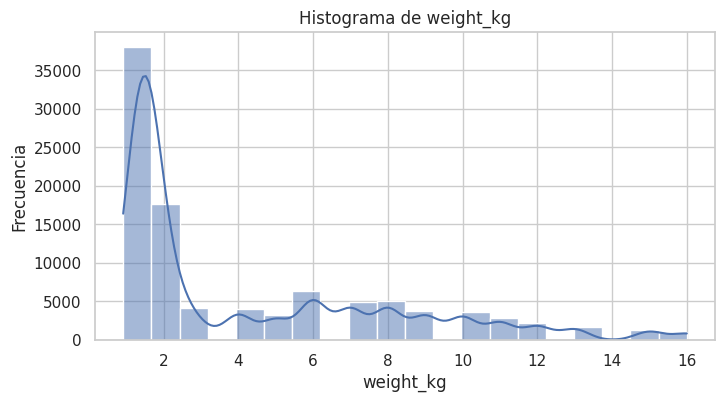

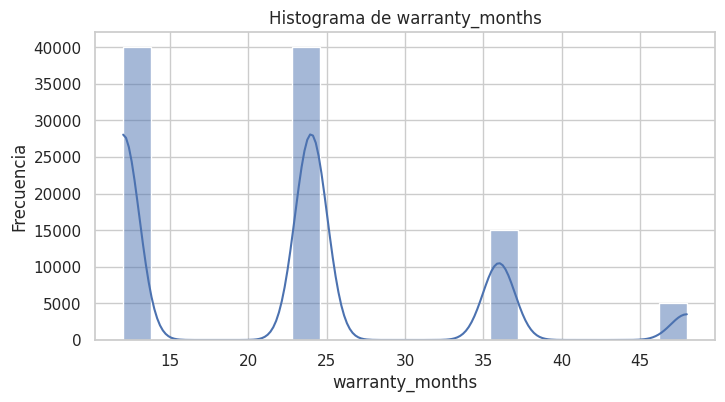

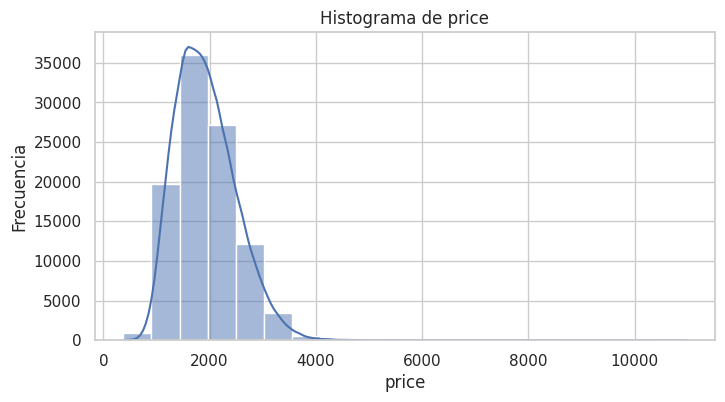


--- Diagramas de Barras para Variables Categóricas ---


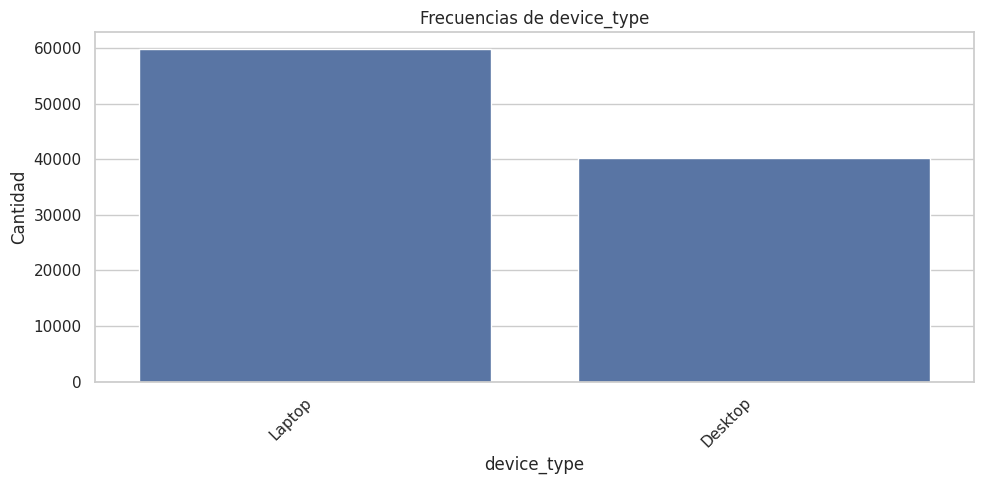

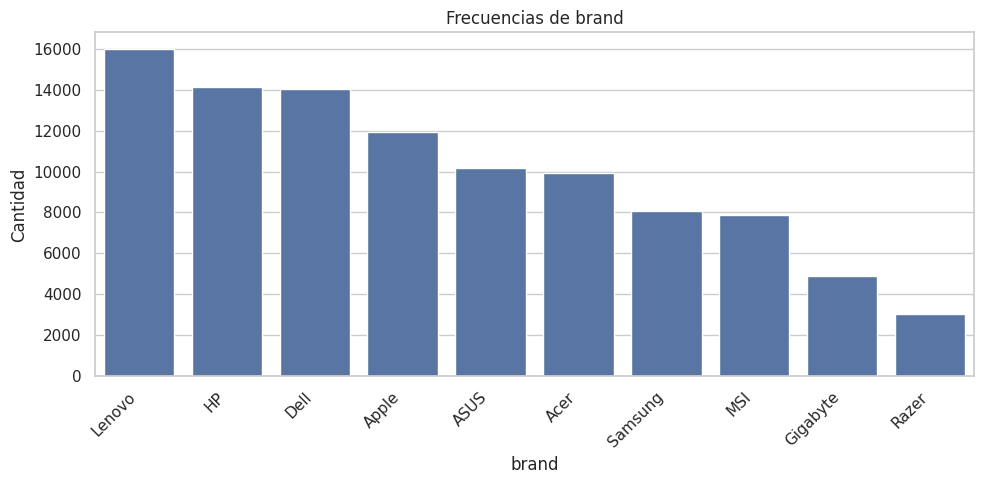

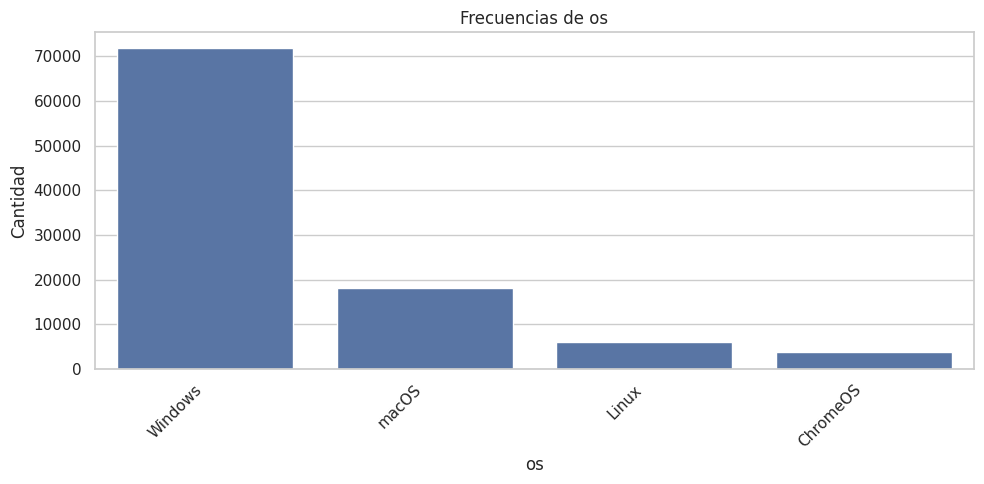

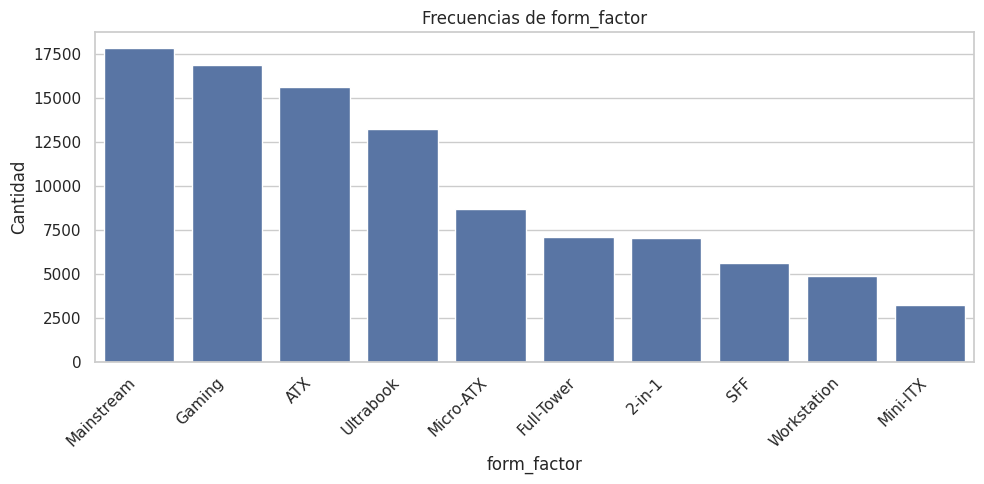

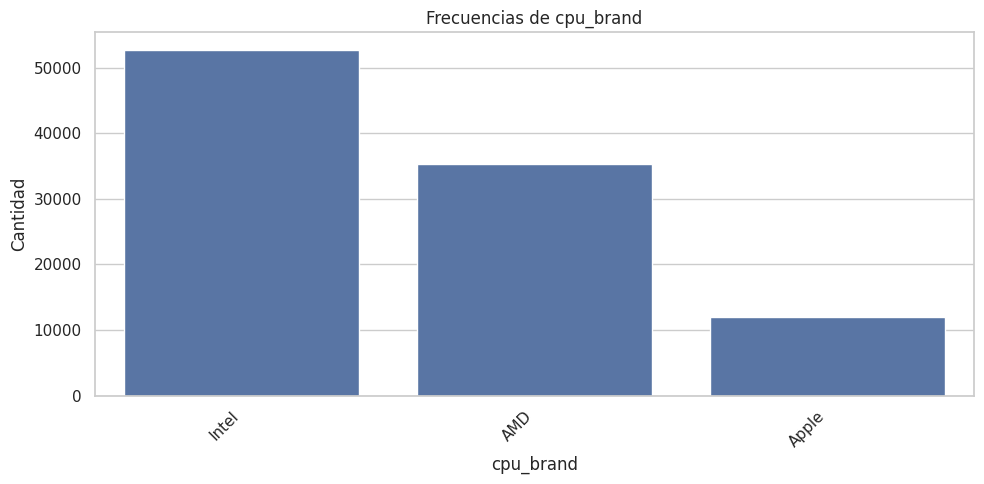

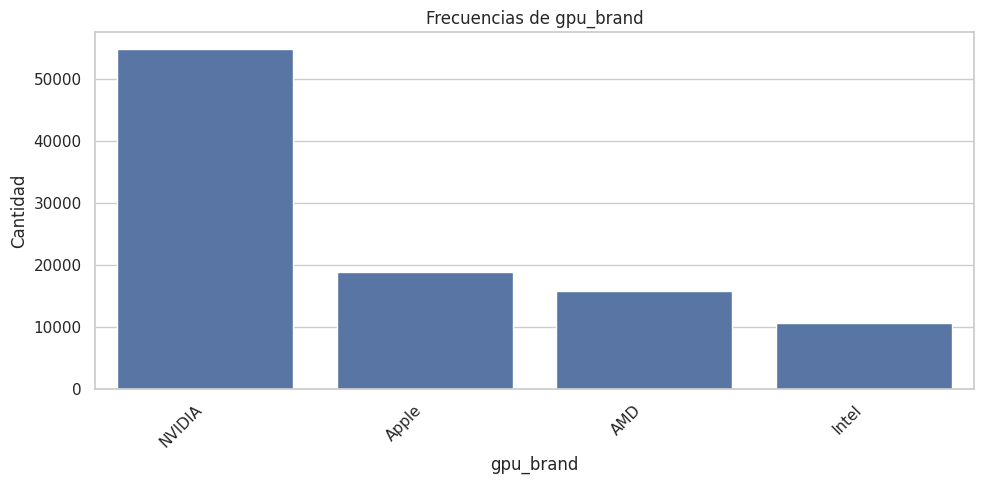

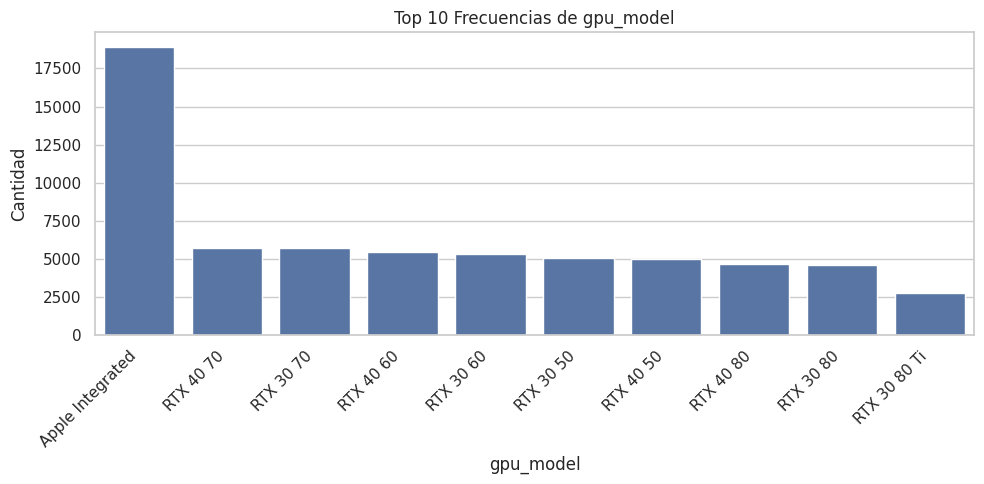

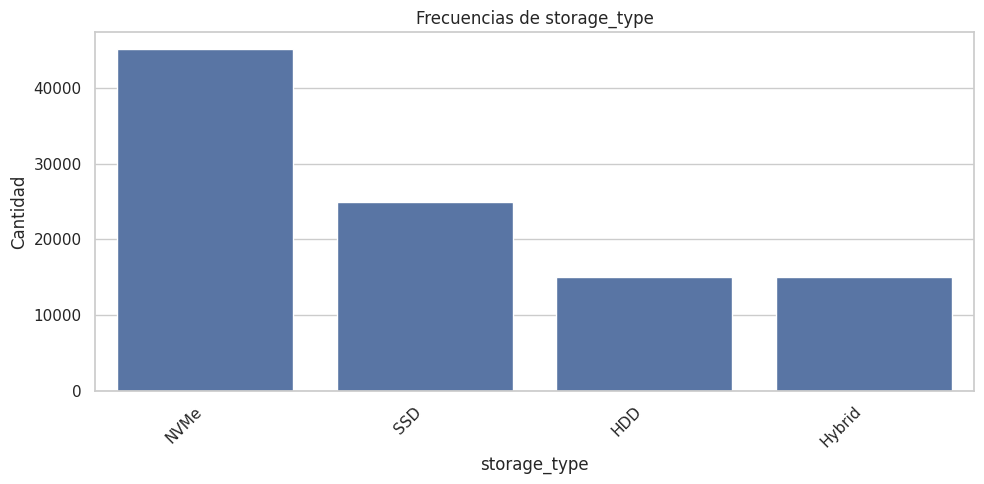

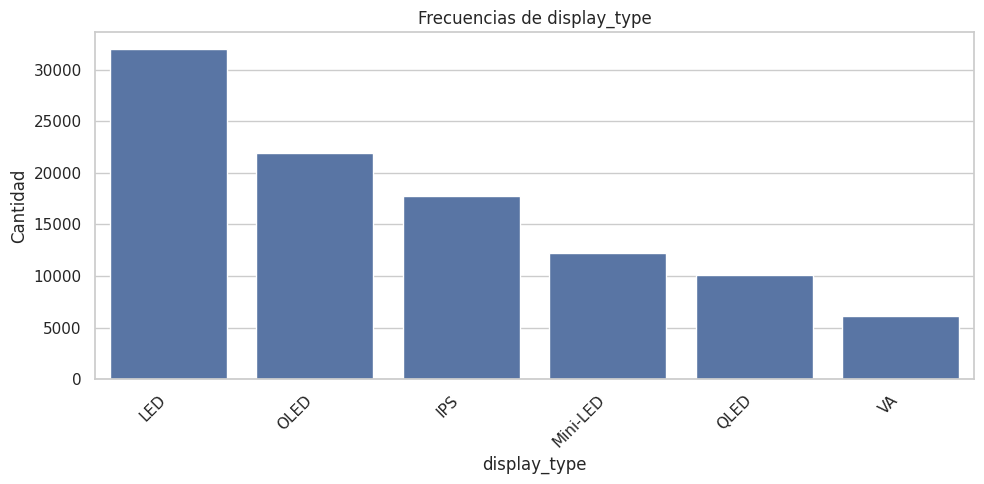

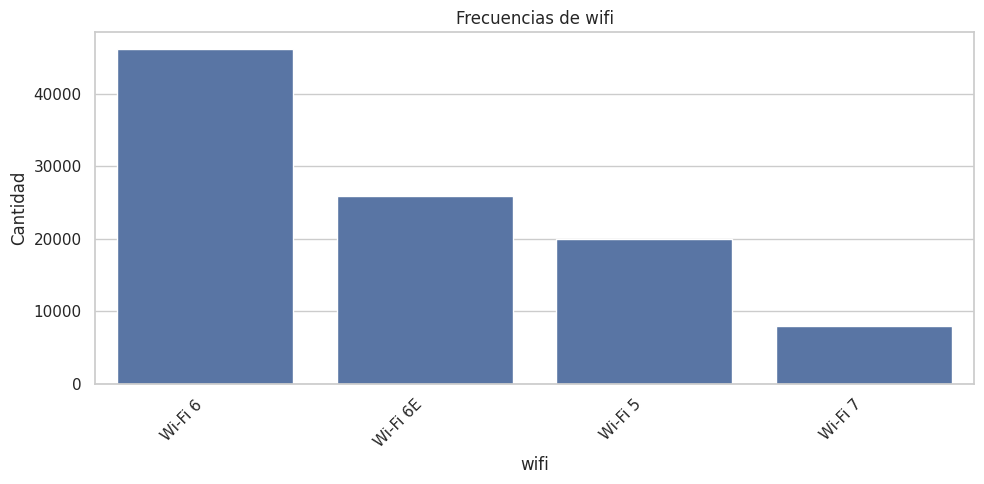

In [6]:
#2.3 Genera histogramas para las numéricas y diagramas de barras para las categóricas.
# Con alta cardinalidad, sólo incluye los 10 valores más frecuentes.

sns.set_theme(style="whitegrid")
def plot_dataframe_distributions(df, top_n=10):

    # Identificar columnas numéricas y categóricas
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    cat_cols = df.select_dtypes(include=['object', 'category']).columns

    # --- Histogramas para numéricas ---
    print("\n--- Histogramas para Variables Numéricas ---")
    for col in num_cols:
        plt.figure(figsize=(8, 4))
        sns.histplot(df[col], kde=True, bins=20)
        plt.title(f'Histograma de {col}')
        plt.xlabel(col)
        plt.ylabel('Frecuencia')
        plt.show()

    # --- Diagramas de barras para categóricas ---
    print("\n--- Diagramas de Barras para Variables Categóricas ---")
    for col in cat_cols:
        plt.figure(figsize=(10, 5))

        # Calcular frecuencias
        freq = df[col].value_counts()

        # Si hay más de top_n valores, tomar solo los top_n
        if len(freq) > top_n:
            order = freq.iloc[:top_n].index
            # Filter data to only include the top_n categories for plotting efficiency
            plot_data = df[df[col].isin(order)]
            plt.title(f'Top {top_n} Frecuencias de {col}')
        else:
            order = freq.index
            plot_data = df # Use full dataframe if not many categories
            plt.title(f'Frecuencias de {col}')

        sns.countplot(data=plot_data, x=col, order=order)
        plt.xticks(rotation=45, ha='right')
        plt.ylabel('Cantidad')
        plt.tight_layout()
        plt.show()

# Llama a la función con tu dataframe
plot_dataframe_distributions(compu_df)


3. Dibuja un mapa de calor con la matriz de correlación para las variables numéricas del conjunto de datos.
* Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos.
* Reflexiona sobre cuáles variables representan de manera general la capacidad del hardware y mantenlas; elimina las demás por aportar información redundante.
* Incluye una breve justificación de tus decisiones.

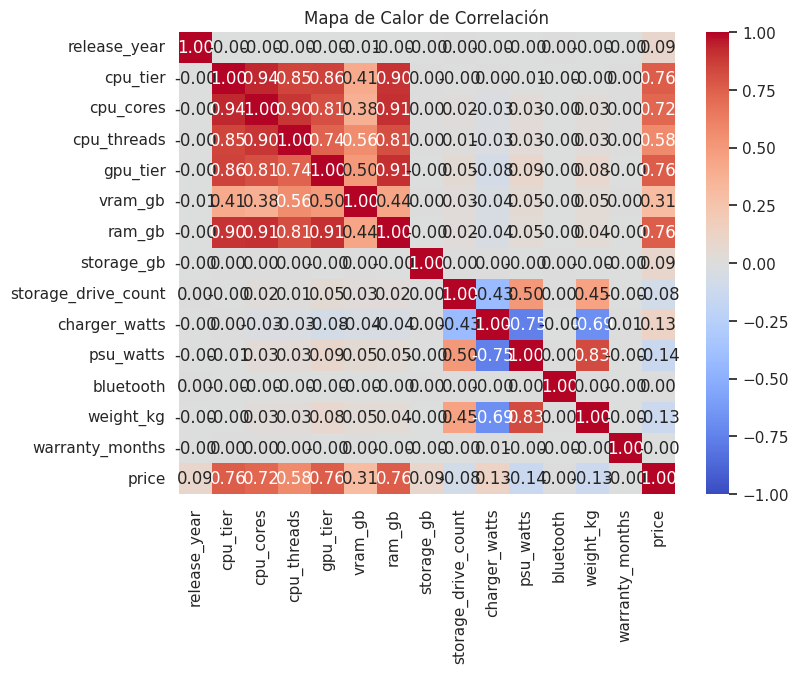

Pares de variables con correlación superior a 0.9:
cpu_tier - cpu_cores: 0.9374
cpu_cores - ram_gb: 0.9068
gpu_tier - ram_gb: 0.9129

Las variables que no se considera necesarias son:
form_factor,cpu_brand,gpu_brand

Se dejaron solo las variables que identifican alguna caracterísitca relevante del hardware.
Al igual que en el caso del modelo, se mantiene solo el tier del gpu al considerarse redundante:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   device_type          100000 non-null  object 
 1   brand                100000 non-null  object 
 2   release_year         100000 non-null  int64  
 3   os                   100000 non-null  object 
 4   cpu_tier             100000 non-null  int64  
 5   cpu_cores            100000 non-null  int64  
 6   cpu_threads          100000 non-null  int64  
 7   gpu_model           

In [7]:
# 3 Calcular la matriz de correlación (solo variables numéricas)
corr_matrix = compu_df.corr(numeric_only=True)

# 3.1 Crear el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Mapa de Calor de Correlación')
plt.show()

#3.2 Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos.
pares_sup = (
    corr_matrix.abs()
    .unstack()
    .drop_duplicates()
)
pares_sup = pares_sup[
    (pares_sup > 0.9) & (pares_sup < 1.0)
]

print("Pares de variables con correlación superior a 0.9:")
for (v1, v2), corr in pares_sup.items():
    print(f"{v1} - {v2}: {corr:.4f}")

#3.3 Reflexiona sobre cuáles variables representan de manera general la capacidad del hardware y mantenlas

#3.4 Elimina las demás por aportar información redundante.
print("\nLas variables que no se considera necesarias son:")
print("form_factor,cpu_brand,gpu_brand")
compu_df.drop(['form_factor','cpu_brand','gpu_brand'], axis=1, inplace=True)


#3.5 Incluye una breve justificación de tus decisiones.
print("\nSe dejaron solo las variables que identifican alguna caracterísitca relevante del hardware.")
print("Al igual que en el caso del modelo, se mantiene solo el tier del gpu al considerarse redundante:")
compu_df.info()



4. Para comenzar con la ingeniería de características, crea una copia del dataframe y asígnala a un nuevo objeto llamado `compu_trans`.
* Calcula cuántos años han pasado desde el lanzamiento de cada computadora y almacénalo en una nueva columna llamada `years_since_release`; luego, elimina la columna original.
* Utiliza `KBinsDiscretizer` para reemplazar la columna `vram_gb` en 4 bins ordinales basados en cuantiles.
* Imprime los valores que delimitan cada bin y haz un histograma para ver la cantidad de observaciones en cada uno, con el fin de entender cómo se agruparon los datos.

In [8]:
# 4 copia del dataframe a uno nuevo
compu_trans = compu_df.copy()

# 4.1 Calcula cuántos años han pasado desde el lanzamiento de cada computadora,
# almacénalo en una nueva columna llamada years_since_release
# elimina la columna original.
current_year = date.today().year
compu_trans['years_since_release'] = current_year - compu_trans['release_year']
compu_trans.drop('release_year', axis=1, inplace=True)
compu_trans.head()


,device_type,brand,os,cpu_tier,cpu_cores,cpu_threads,gpu_model,gpu_tier,vram_gb,ram_gb,...,storage_drive_count,display_type,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price,years_since_release
0,Desktop,Samsung,Windows,3,12,24,RTX 40 60,2,6,16,...,1,LED,0,750,Wi-Fi 6,5.1,11.00,36,1383.99,4
1,Laptop,Samsung,Windows,4,12,24,RTX 40 80,4,10,64,...,1,OLED,120,0,Wi-Fi 6,5.3,2.03,12,2274.99,4
2,Desktop,Lenovo,macOS,2,8,16,RTX 40 50,1,4,8,...,2,LED,0,850,Wi-Fi 6,5.0,7.00,24,1879.99,2
3,Desktop,Dell,Windows,2,6,12,RX 7000 60,2,6,16,...,2,IPS,0,650,Wi-Fi 6,5.2,6.00,36,1331.99,2
4,Laptop,Gigabyte,Linux,5,16,32,RTX 30 80 Ti,5,12,96,...,1,Mini-LED,90,0,Wi-Fi 6,5.2,1.50,12,2681.99,2


Límites de los bins para vram_gb:
Bin 0: [0.00, 4.00)
Bin 1: [4.00, 6.00)
Bin 2: [6.00, 8.00)
Bin 3: [8.00, 16.00)


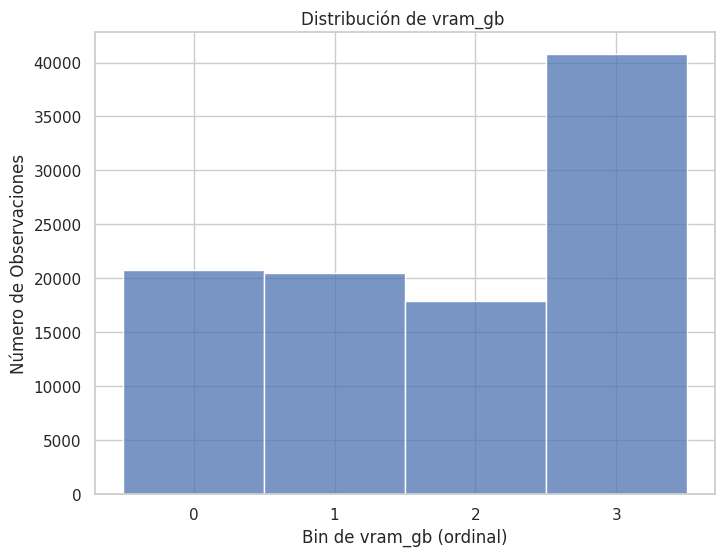

In [9]:
#4.2 Utiliza KBinsDiscretizer para reemplazar la columna vram_gb en 4 bins ordinales basados en cuantiles.

k_bins = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile', subsample=None, random_state=42)
compu_trans['vram_gb'] = k_bins.fit_transform(compu_trans[['vram_gb']])

#4.3 Imprime los valores que delimitan cada bin
print("Límites de los bins para vram_gb:")
for i, edge in enumerate(k_bins.bin_edges_[0]):
    if i < len(k_bins.bin_edges_[0]) - 1:
        print(f"Bin {i}: [{edge:.2f}, {k_bins.bin_edges_[0][i+1]:.2f})")

# 4.4 Haz un histograma para ver la cantidad de observaciones en cada uno,
# con el fin de entender cómo se agruparon los datos.
plt.figure(figsize=(8, 6))
sns.histplot(compu_trans['vram_gb'], bins=4, kde=False, discrete=True)
plt.title('Distribución de vram_gb ')
plt.xlabel('Bin de vram_gb (ordinal)')
plt.ylabel('Número de Observaciones')
plt.xticks(ticks=[0, 1, 2, 3])
plt.show()

5. Observa los histogramas del ejercicio 2. Notarás que en las variables `charger_watts` y `psu_watts` aparece una barra en 0. Analiza por qué ocurre esto y qué significa en relación con el tipo de dispositivo.
* Como estas variables son mutuamente excluyentes, combínalas en una nueva columna llamada `power_watts` que contenga la potencia correspondiente de cada dispositivo y, a continuación, haz un histograma para verificar que la distribución resultante es bimodal.
* Por último, borra las columnas originales `charger_watts` y `psu_watts`.

In [10]:
#5 Observa los histogramas del ejercicio 2.
#Analiza por qué charger_watts y psu_watts aparece una barra en 0
print ("""
Las variables charger_watts y psu_watts se muestran en cero porque dependen de la variable device_type y se consideran mutuamente excluyentes.
1. En las "laptops", "charger_watts" indica la potencia de su cargador, por lo que "psu_watts" será igual 0 que hace referencia a las fuentes internas de las desktops.
2. En las "desktops", "psu_watts" indica la potencia de su fuente de poder, mientras que "charger_watts" tendrá un valor de 0 porque solo le aplica a laptops.
Esto significa que la barra en 0 en los histogramas representa la cantidad de dispositivos para los cuales esa característica particular es aplicable
       """)


Las variables charger_watts y psu_watts se muestran en cero porque dependen de la variable device_type y se consideran mutuamente excluyentes.
1. En las "laptops", "charger_watts" indica la potencia de su cargador, por lo que "psu_watts" será igual 0 que hace referencia a las fuentes internas de las desktops.
2. En las "desktops", "psu_watts" indica la potencia de su fuente de poder, mientras que "charger_watts" tendrá un valor de 0 porque solo le aplica a laptops.
Esto significa que la barra en 0 en los histogramas representa la cantidad de dispositivos para los cuales esa característica particular es aplicable
       


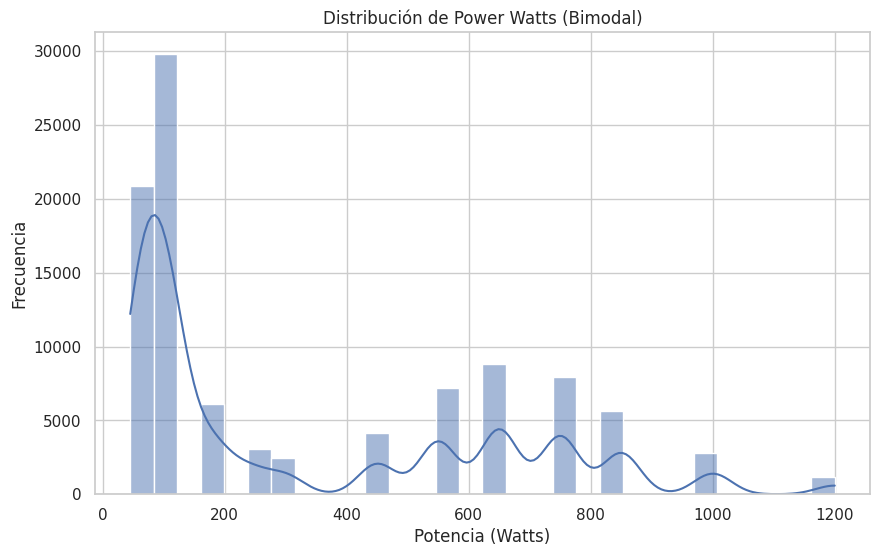

,device_type,brand,os,cpu_tier,cpu_cores,cpu_threads,gpu_model,gpu_tier,vram_gb,ram_gb,...,storage_gb,storage_drive_count,display_type,wifi,bluetooth,weight_kg,warranty_months,price,years_since_release,power_watts
0,Desktop,Samsung,Windows,3,12,24,RTX 40 60,2,2.0,16,...,1024,1,LED,Wi-Fi 6,5.1,11.00,36,1383.99,4,750
1,Laptop,Samsung,Windows,4,12,24,RTX 40 80,4,3.0,64,...,512,1,OLED,Wi-Fi 6,5.3,2.03,12,2274.99,4,120
2,Desktop,Lenovo,macOS,2,8,16,RTX 40 50,1,1.0,8,...,512,2,LED,Wi-Fi 6,5.0,7.00,24,1879.99,2,850
3,Desktop,Dell,Windows,2,6,12,RX 7000 60,2,2.0,16,...,512,2,IPS,Wi-Fi 6,5.2,6.00,36,1331.99,2,650
4,Laptop,Gigabyte,Linux,5,16,32,RTX 30 80 Ti,5,3.0,96,...,256,1,Mini-LED,Wi-Fi 6,5.2,1.50,12,2681.99,2,90


In [11]:
#5.1 Como estas variables son mutuamente excluyentes,
#combínalas en una nueva columna llamada power_watts
#que contenga la potencia correspondiente de cada dispositivo
compu_trans['power_watts'] = compu_trans['charger_watts'] + compu_trans['psu_watts']


#5.1.1. Haz un histograma para verificar que la distribución resultante es bimodal.
plt.figure(figsize=(10, 6))
sns.histplot(compu_trans['power_watts'], bins=30, kde=True)
plt.title('Distribución de Power Watts (Bimodal)')
plt.xlabel('Potencia (Watts)')
plt.ylabel('Frecuencia')
plt.show()

# Borra las columnas originales charger_watts y psu_watts
compu_trans.drop(['charger_watts', 'psu_watts'], axis=1, inplace=True)
compu_trans.head()


6. Para disminuir el sesgo de la variable `price`, crea tres transformadores: logaritmo, raíz cuadrada y Box - Cox.
* Aplica cada transformador a la variable price, dejando el resultado en variables temporales. El objetivo es comparar los efectos de cada transformación antes de decidir cuál aplicar de manera definitiva sobre las variables continuas del dataframe.
* De la variable original y de cada una de las tres transformaciones se debe mostrar:
  * Histograma: para observar la distribución de los datos.
  * Boxplot: para identificar posibles valores atípicos.
  * Q-Q plot: para evaluar la normalidad de la variable.
  * Skew (sesgo): para cuantificar la asimetría de la distribución.
  * Cantidad de outliers: para conocer cuántos valores extremos existen.
* En función de los resultados obtenidos al comparar las transformaciones, decide cuál logró el mejor efecto sobre la distribución de la variable y aplícala directamente en el dataframe, reemplazando las variables continuas: `weight_kg`, `power_watts` y `price`.


--- Análisis para: Price Original ---
Skewness: 0.9866
Cantidad de Outliers (IQR): 976


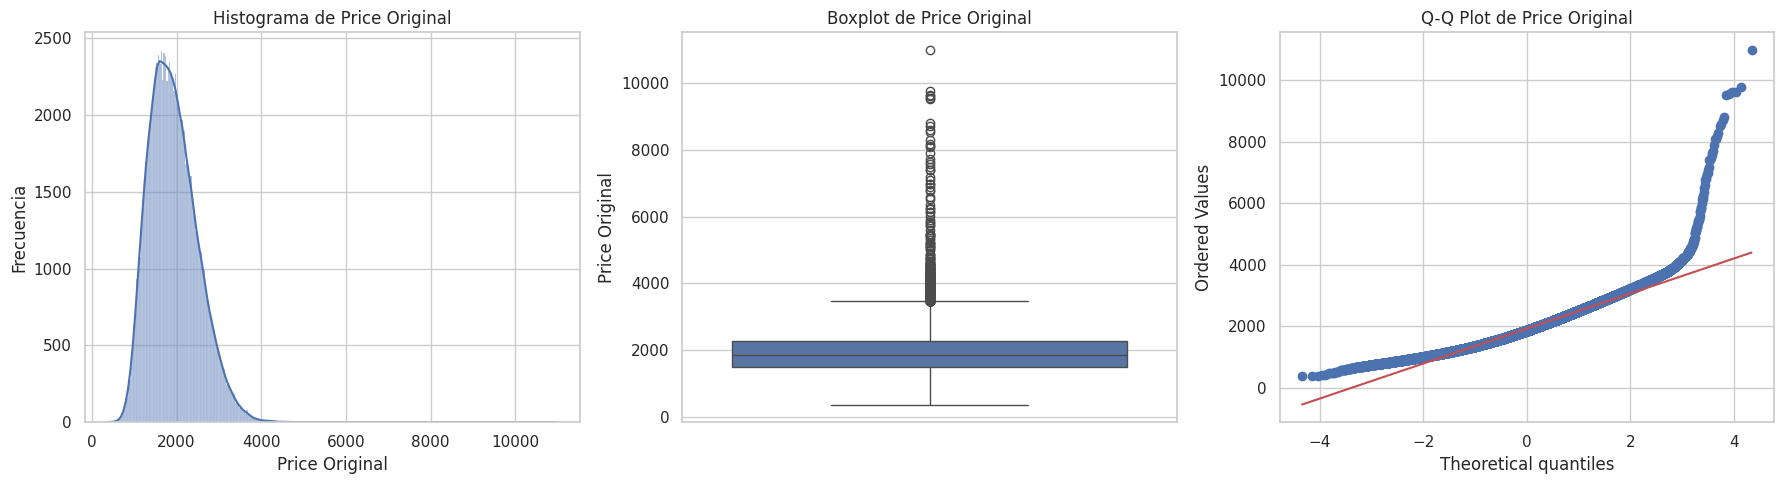


--- Análisis para: Price (Log Transformado) ---
Skewness: -0.1326
Cantidad de Outliers (IQR): 387


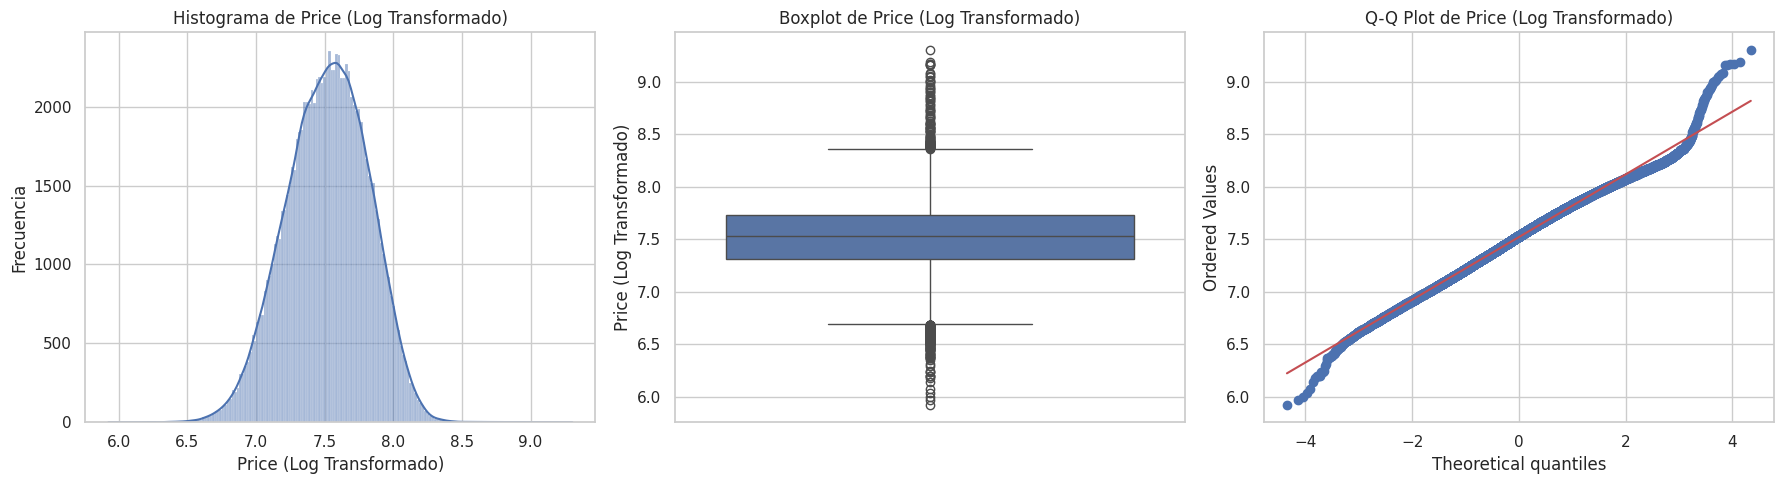


--- Análisis para: Price (Raíz Cuadrada Transformado) ---
Skewness: 0.3323
Cantidad de Outliers (IQR): 364


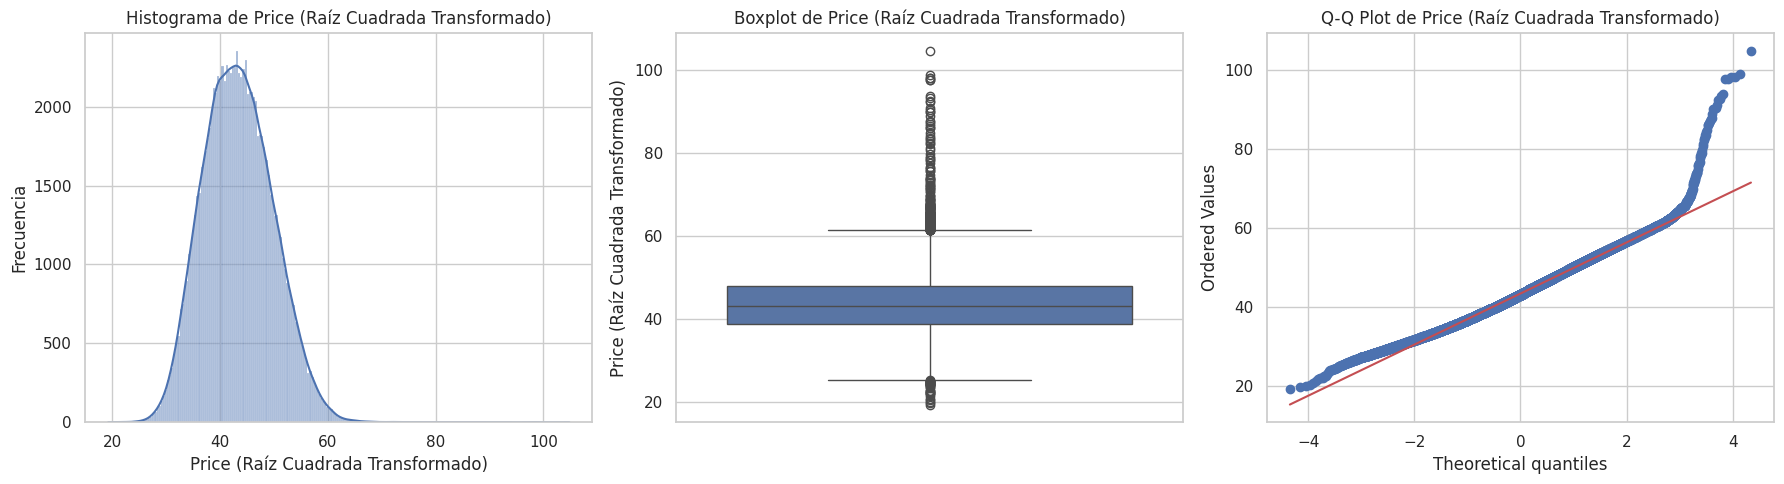


--- Análisis para: Price (Box-Cox Transformado) ---
Skewness: -0.0002
Cantidad de Outliers (IQR): 317


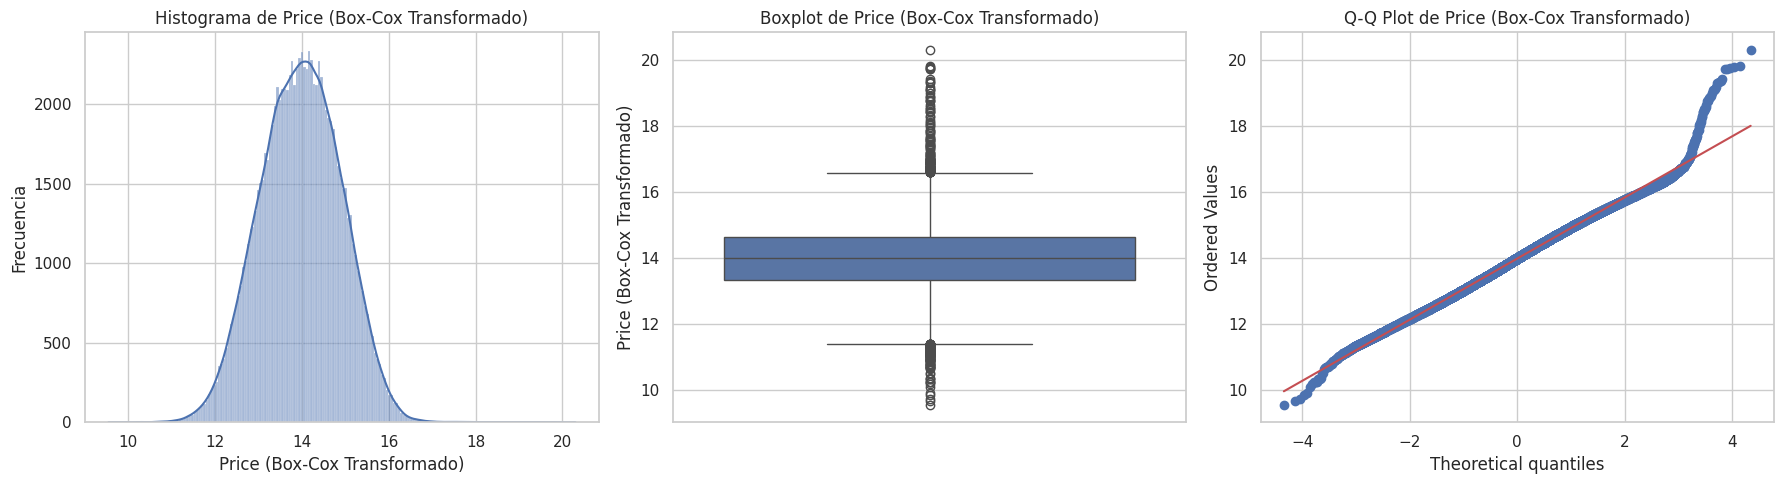


      Elegimos Box-Cox por su capacidad de manejar mejor la normalidad
      y su ver versatilidad en este ejemplo.
       
Valor mínimo de precio: 372.99
Valor mínimo de power_watts: 45
Valor mínimo de weight_kg: 0.92

--- DataFrame después de aplicar Box-Cox a 'weight_kg', 'price' y 'power_watts' ---


,device_type,brand,os,cpu_tier,cpu_cores,cpu_threads,gpu_model,gpu_tier,vram_gb,ram_gb,...,wifi,bluetooth,weight_kg,warranty_months,price,years_since_release,power_watts,price_log,price_sqrt,price_boxcox
0,Desktop,Samsung,Windows,3,12,24,RTX 40 60,2,2.0,16,...,Wi-Fi 6,5.1,1.423738,36,13.084409,4,4.027279,7.233448,37.202016,13.084409
1,Laptop,Samsung,Windows,4,12,24,RTX 40 80,4,3.0,64,...,Wi-Fi 6,5.3,0.600182,12,14.616126,4,3.309631,7.730170,47.696855,14.616126
2,Desktop,Lenovo,macOS,2,8,16,RTX 40 50,1,1.0,8,...,Wi-Fi 6,5.0,1.264216,24,14.014803,2,4.068824,7.539554,43.358851,14.014803
3,Desktop,Dell,Windows,2,6,12,RX 7000 60,2,2.0,16,...,Wi-Fi 6,5.2,1.201393,36,12.971066,2,3.978717,7.195180,36.496438,12.971066
4,Laptop,Gigabyte,Linux,5,16,32,RTX 30 80 Ti,5,3.0,96,...,Wi-Fi 6,5.2,0.368418,12,15.149121,2,3.175932,7.894687,51.787933,15.149121


In [12]:
# Cálculo de outliers usando el método IQR
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return len(outliers)

# Función para graficar y obtener métricas
def analyze_distribution(data, title):
    print(f"\n--- Análisis para: {title} ---")

    # Skewness
    skewness = data.skew()
    print(f"Skewness: {skewness:.4f}")

    # Outliers
    outliers_count = count_outliers_iqr(data)
    print(f"Cantidad de Outliers (IQR): {outliers_count}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Histograma
    sns.histplot(data, kde=True, ax=axes[0])
    axes[0].set_title(f'Histograma de {title}')
    axes[0].set_xlabel(title)
    axes[0].set_ylabel('Frecuencia')

    # Boxplot
    sns.boxplot(y=data, ax=axes[1])
    axes[1].set_title(f'Boxplot de {title}')
    axes[1].set_ylabel(title)

    # Q-Q plot
    probplot(data, dist="norm", plot=axes[2])
    axes[2].set_title(f'Q-Q Plot de {title}')

    plt.tight_layout()
    plt.show()

# Crear variables temporales para las transformaciones de 'price'
compu_trans['price_log'] = np.log1p(compu_trans['price'])
compu_trans['price_sqrt'] = np.sqrt(compu_trans['price'])

# Usamos PowerTransformer para Box-Cox y Johnson
pt = PowerTransformer(method='box-cox', standardize=False)
compu_trans['price_boxcox'] = pt.fit_transform(compu_trans[['price']] + 1e-6)

# Realizar el análisis para la variable original y las transformadas
analyze_distribution(compu_trans['price'], 'Price Original')
analyze_distribution(compu_trans['price_log'], 'Price (Log Transformado)')
analyze_distribution(compu_trans['price_sqrt'], 'Price (Raíz Cuadrada Transformado)')
analyze_distribution(compu_trans['price_boxcox'], 'Price (Box-Cox Transformado)')

print("""
      Elegimos Box-Cox por su capacidad de manejar mejor la normalidad
      y su ver versatilidad en este ejemplo.
       """)

# Aplicar la transformación Box-Cox a las variables continuas 'weight_kg','price', 'power_watts'

print(f"Valor mínimo de precio: {compu_trans['price'].min()}")
print(f"Valor mínimo de power_watts: {compu_trans['power_watts'].min()}")
print(f"Valor mínimo de weight_kg: {compu_trans['weight_kg'].min()}")

pt_price = PowerTransformer(method='box-cox', standardize=False)
compu_trans['price'] = pt_price.fit_transform(compu_trans[['price']] + 1e-6).flatten()
pt_power_watts = PowerTransformer(method='box-cox', standardize=False)
compu_trans['power_watts'] = pt_power_watts.fit_transform(compu_trans[['power_watts']] + 1e-6).flatten()
pt_weight_kg = PowerTransformer(method='box-cox', standardize=False)
compu_trans['weight_kg'] = pt_weight_kg.fit_transform(compu_trans[['weight_kg']] + 1e-6).flatten()

#compu_trans.drop(columns=['price_log', 'price_sqrt', 'price_boxcox'], inplace=True)
print("\n--- DataFrame después de aplicar Box-Cox a 'weight_kg', 'price' y 'power_watts' ---")
compu_trans.head()

7. Para que todas las variables numéricas estén en la misma escala, aplica `MinMaxScaler` de sklearn a todas las columnas numéricas del dataframe, reemplazando las columnas originales.

In [13]:
from sklearn.preprocessing import MinMaxScaler

# Identificar todas las columnas numericas que se las aplicara la escala
cols_num_conv = compu_trans.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Aplicando MinMaxScaler
scaler = MinMaxScaler()
compu_trans[cols_num_conv] = scaler.fit_transform(compu_trans[cols_num_conv])
display(compu_trans.describe())

,cpu_tier,cpu_cores,cpu_threads,gpu_tier,vram_gb,ram_gb,storage_gb,storage_drive_count,bluetooth,weight_kg,warranty_months,price,years_since_release,power_watts,price_log,price_sqrt,price_boxcox
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.430698,0.271489,0.295629,0.398270,0.595883,0.233135,0.168733,0.174993,0.804331,0.517032,0.283343,0.411800,0.382736,0.499405,0.472376,0.282170,0.411800
std,0.274635,0.210171,0.186893,0.291929,0.394170,0.234579,0.201626,0.265761,0.223616,0.293982,0.284219,0.086261,0.289394,0.313894,0.088567,0.075760,0.086261
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.200000,0.083333,0.153846,0.200000,0.333333,0.058824,0.066667,0.000000,0.727273,0.280423,0.000000,0.351779,0.142857,0.258382,0.411909,0.227710,0.351779
50%,0.400000,0.166667,0.230769,0.400000,0.666667,0.176471,0.066667,0.000000,0.818182,0.417162,0.333333,0.412776,0.285714,0.357238,0.475359,0.279088,0.412776
75%,0.600000,0.416667,0.384615,0.600000,1.000000,0.411765,0.200000,0.333333,0.909091,0.834353,0.333333,0.472899,0.571429,0.851953,0.535964,0.333581,0.472899
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


8. Aunque `wifi` es una variable categórica, sus categorías tienen un orden natural (Wi-Fi 5 < Wi-Fi 6 < Wi-Fi 6E < Wi-Fi 7). Codifícala usando `OrdinalEncoder`.
* Luego, escala la variable codificada entre 0 y 1 con `MinMaxScaler`, para que quede en la misma escala que las variables numéricas del dataframe.

Nota: Ambos cambios deben efectuarse sobre la columna original, de manera que quede una única columna `wifi` con toda la información transformada.

In [14]:
# 8. Codificar la variable 'wifi' usando OrdinalEncoder y luego escalarla con MinMaxScaler


orden_wifi = ['Wi-Fi 5', 'Wi-Fi 6', 'Wi-Fi 6E', 'Wi-Fi 7']
ordinal_encoder = OrdinalEncoder(categories=[orden_wifi])
compu_trans['wifi'] = ordinal_encoder.fit_transform(compu_trans[['wifi']])
min_max_scaler = MinMaxScaler()

# Escalar la variable 'wifi' codificada entre 0 y 1
compu_trans['wifi'] = min_max_scaler.fit_transform(compu_trans[['wifi']])

print("Resultado de la transformación:")
display(compu_trans.head())



Resultado de la transformación:


,device_type,brand,os,cpu_tier,cpu_cores,cpu_threads,gpu_model,gpu_tier,vram_gb,ram_gb,...,wifi,bluetooth,weight_kg,warranty_months,price,years_since_release,power_watts,price_log,price_sqrt,price_boxcox
0,Desktop,Samsung,Windows,0.4,0.333333,0.384615,RTX 40 60,0.2,0.666667,0.058824,...,0.333333,0.818182,0.932995,0.666667,0.328669,0.428571,0.887860,0.387326,0.209238,0.328669
1,Laptop,Samsung,Windows,0.6,0.333333,0.384615,RTX 40 80,0.6,1.000000,0.411765,...,0.333333,1.000000,0.423737,0.000000,0.471202,0.428571,0.357238,0.534279,0.331990,0.471202
2,Desktop,Lenovo,macOS,0.2,0.166667,0.230769,RTX 40 50,0.0,0.333333,0.000000,...,0.333333,0.727273,0.834353,0.333333,0.415246,0.142857,0.918578,0.477886,0.281251,0.415246
3,Desktop,Dell,Windows,0.2,0.083333,0.153846,RX 7000 60,0.2,0.666667,0.058824,...,0.333333,0.909091,0.795505,0.666667,0.318122,0.142857,0.851953,0.376005,0.200985,0.318122
4,Laptop,Gigabyte,Linux,0.8,0.500000,0.538462,RTX 30 80 Ti,0.8,1.000000,0.647059,...,0.333333,0.909091,0.280423,0.000000,0.520800,0.142857,0.258382,0.582950,0.379841,0.520800


9. La variable `gpu_model` tiene muchas categorías. Usar *One-Hot Encoding* aumentaría significativamente la dimensionalidad del dataframe. Por ello, utiliza `BinaryEncoder` para codificarla.
* Guarda el resultado en un dataframe llamado `bin_df`. Más adelante, lo combinarás con `compu_transf` para integrar las variables codificadas.

In [15]:
from category_encoders.binary import BinaryEncoder

# 9. Codificar gpu_model usando BinaryEncoder
encoder = BinaryEncoder(cols=['gpu_model'], handle_unknown='impute')
bin_df = encoder.fit_transform(compu_trans['gpu_model'])

# Muestra dataframe final
print("DataFrame codificado con BinaryEncoder para 'gpu_model':")
display(bin_df.head())


DataFrame codificado con BinaryEncoder para 'gpu_model':


,gpu_model_0,gpu_model_1,gpu_model_2,gpu_model_3,gpu_model_4,gpu_model_5
0,0,0,0,0,0,1
1,0,0,0,0,1,0
2,0,0,0,0,1,1
3,0,0,0,1,0,0
4,0,0,0,1,0,1


10. Usa `OneHotEncoder` para codificar las variables categóricas restantes. Asegúrate de usar `drop='first'` para evitar la multicolinealidad y guarda el resultado en un dataframe llamado `ohe_df`
* Combina el dataframe `compu_transf` con las variables categóricas que fueron codificadas en `bin_df` y `ohe_df`. No olvides eliminar las variables originales.
* Usa `describe()` sobre el dataframe resultante para corroborar que todas las columnas estén escaladas entre 0 y 1 y que no queden variables categóricas sin codificar.

In [16]:
from sklearn.preprocessing import OneHotEncoder

#9 Usar ONeHotEncoder para codificar variables categóricas restantes
cols_catforOHE = compu_trans.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Columnas categóricas a codificar con OneHotEncoder: {cols_catforOHE}")

OHE_encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

#9.1 Aplicar OneHotEncoder a las columnas identificadas
ohe_features = OHE_encoder.fit_transform(compu_trans[cols_catforOHE])


OHE_df = pd.DataFrame(
    ohe_features,
    columns=OHE_encoder.get_feature_names_out(cols_catforOHE),
    index=compu_trans.index
)

print("DataFrame codificado con OneHotEncoder:")
display(OHE_df.head())


#9.2 Combinar compu_trans_final, bin_df y ohe_df
compu_trans_comb = compu_trans.drop(columns=cols_catforOHE, axis=1)
final_df = pd.concat([compu_trans_comb, bin_df, OHE_df], axis=1)

print("\nDataFrame combinado:")
display(final_df.head())

# Usar describe() sobre el dataframe resultante para corroborar:
# 1. Que todas las columnas numéricas (incluidas las codificadas) estén escaladas entre 0 y 1.
# 2. Que no queden variables categóricas sin codificar.

print("\nEstadísticas descriptivas del DataFrame final para corroborar escalado (min=0, max=1):")
display(final_df.describe())

print("\nColumnas del DataFrame final con tipos de datos 'object' o 'category' (debería estar vacío):")
display(final_df.select_dtypes(include=['object', 'category']).columns)



Columnas categóricas a codificar con OneHotEncoder: ['device_type', 'brand', 'os', 'gpu_model', 'storage_type', 'display_type']
DataFrame codificado con OneHotEncoder:


,device_type_Laptop,brand_Acer,brand_Apple,brand_Dell,brand_Gigabyte,brand_HP,brand_Lenovo,brand_MSI,brand_Razer,brand_Samsung,...,gpu_model_RX 7000 80 XT,gpu_model_RX 7000 90,storage_type_Hybrid,storage_type_NVMe,storage_type_SSD,display_type_LED,display_type_Mini-LED,display_type_OLED,display_type_QLED,display_type_VA
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0



DataFrame combinado:


,cpu_tier,cpu_cores,cpu_threads,gpu_tier,vram_gb,ram_gb,storage_gb,storage_drive_count,wifi,bluetooth,...,gpu_model_RX 7000 80 XT,gpu_model_RX 7000 90,storage_type_Hybrid,storage_type_NVMe,storage_type_SSD,display_type_LED,display_type_Mini-LED,display_type_OLED,display_type_QLED,display_type_VA
0,0.4,0.333333,0.384615,0.2,0.666667,0.058824,0.200000,0.000000,0.333333,0.818182,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.6,0.333333,0.384615,0.6,1.000000,0.411765,0.066667,0.000000,0.333333,1.000000,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.2,0.166667,0.230769,0.0,0.333333,0.000000,0.066667,0.333333,0.333333,0.727273,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.2,0.083333,0.153846,0.2,0.666667,0.058824,0.066667,0.333333,0.333333,0.909091,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.8,0.500000,0.538462,0.8,1.000000,0.647059,0.000000,0.000000,0.333333,0.909091,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0



Estadísticas descriptivas del DataFrame final para corroborar escalado (min=0, max=1):


,cpu_tier,cpu_cores,cpu_threads,gpu_tier,vram_gb,ram_gb,storage_gb,storage_drive_count,wifi,bluetooth,...,gpu_model_RX 7000 80 XT,gpu_model_RX 7000 90,storage_type_Hybrid,storage_type_NVMe,storage_type_SSD,display_type_LED,display_type_Mini-LED,display_type_OLED,display_type_QLED,display_type_VA
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.430698,0.271489,0.295629,0.398270,0.595883,0.233135,0.168733,0.174993,0.406670,0.804331,...,0.008140,0.003540,0.149810,0.450590,0.249370,0.320000,0.121880,0.219100,0.100690,0.060910
std,0.274635,0.210171,0.186893,0.291929,0.394170,0.234579,0.201626,0.265761,0.284834,0.223616,...,0.089854,0.059393,0.356887,0.497555,0.432651,0.466478,0.327149,0.413639,0.300919,0.239166
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.200000,0.083333,0.153846,0.200000,0.333333,0.058824,0.066667,0.000000,0.333333,0.727273,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.400000,0.166667,0.230769,0.400000,0.666667,0.176471,0.066667,0.000000,0.333333,0.818182,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.600000,0.416667,0.384615,0.600000,1.000000,0.411765,0.200000,0.333333,0.666667,0.909091,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



Columnas del DataFrame final con tipos de datos 'object' o 'category' (debería estar vacío):


Index([], dtype='object')